# 라벨 유무 분포 진단
실제 원본 전수 검사. 미라벨의 정답이나 라벨 수집 원인을 추정하지 않는다.

In [1]:

from pathlib import Path
import hashlib, json, platform
from datetime import datetime, timezone
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'src/features.py').exists())
OUT = ROOT/'output'/'label_coverage'
OUT.mkdir(exist_ok=True)
source = ROOT/'data/train.csv'
assert source.is_file(), '실제 데이터가 없으면 중단'
df = pd.read_csv(source)
known = df.Delay.notna()
assert set(df.loc[known, 'Delay'].unique()) <= {'Delayed', 'Not_Delayed'}
counts = {'rows': len(df), 'columns': len(df.columns), 'labeled': int(known.sum()),
          'unlabeled': int((~known).sum()), 'positive': int(df.Delay.eq('Delayed').sum()),
          'label_rate': float(known.mean()), 'duplicate_id': int(df.ID.duplicated().sum()),
          'duplicate_rows': int(df.duplicated().sum())}
counts['positive_rate_labeled'] = counts['positive']/counts['labeled']
assert counts['labeled'] + counts['unlabeled'] == counts['rows']
missing = pd.DataFrame({'column': df.columns,
    'labeled_missing_n': df[known].isna().sum().values,
    'unlabeled_missing_n': df[~known].isna().sum().values})
missing['labeled_missing_pct'] = missing.labeled_missing_n/counts['labeled']*100
missing['unlabeled_missing_pct'] = missing.unlabeled_missing_n/counts['unlabeled']*100
missing['delta_pp'] = missing.unlabeled_missing_pct-missing.labeled_missing_pct
missing.to_csv(OUT/'missingness.csv', index=False)
schema = pd.DataFrame({'column': df.columns, 'dtype': df.dtypes.astype(str).values,
    'missing_n': df.isna().sum().values, 'nunique': df.nunique().values})
schema.to_csv(OUT/'schema.csv', index=False)
parts, summaries = [], []
cols = ['Month','Day_of_Month','Airline','Carrier_Code(IATA)',
        'Origin_Airport','Destination_Airport','Origin_State','Destination_State','Tail_Number']
for col in cols:
    s = df[col].astype('string').fillna('<MISSING>')
    g = pd.DataFrame({'category': s, 'labeled_n': known.astype(int),
                      'positive_n': df.Delay.eq('Delayed').astype(int)})
    g = g.groupby('category', dropna=False).agg(total_n=('labeled_n','size'),
        labeled_n=('labeled_n','sum'), positive_n=('positive_n','sum')).reset_index()
    g['unlabeled_n'] = g.total_n-g.labeled_n
    g['labeled_share'] = g.labeled_n/counts['labeled']
    g['unlabeled_share'] = g.unlabeled_n/counts['unlabeled']
    g['delta_pp'] = 100*(g.unlabeled_share-g.labeled_share)
    g['label_rate_pct'] = g.labeled_n/g.total_n*100
    g['observed_delay_rate'] = g.positive_n/g.labeled_n.replace(0,np.nan)
    g.insert(0,'column',col)
    assert g.total_n.sum() == len(df)
    assert np.isclose(g.labeled_share.sum(),1) and np.isclose(g.unlabeled_share.sum(),1)
    parts.append(g)
    summaries.append({'column':col,'categories':len(g),
        'total_variation':float((g.labeled_share-g.unlabeled_share).abs().sum()/2),
        'max_share_gap_pp':float(g.delta_pp.abs().max()),
        'unlabeled_rows_in_unseen_categories':int(g.loc[g.labeled_n.eq(0),'unlabeled_n'].sum()),
        'unlabeled_unseen_pct':float(g.loc[g.labeled_n.eq(0),'unlabeled_n'].sum()/counts['unlabeled']*100)})
groups=pd.concat(parts,ignore_index=True)
dist=pd.DataFrame(summaries).sort_values('total_variation',ascending=False)
groups.to_csv(OUT/'group_distributions.csv',index=False)
dist.to_csv(OUT/'distribution_summary.csv',index=False)
numeric=[]
for col in ['Distance','Estimated_Departure_Time','Estimated_Arrival_Time']:
    a=df.loc[known,col].dropna(); b=df.loc[~known,col].dropna()
    pooled=np.sqrt((a.var()+b.var())/2)
    row={'column':col,'labeled_n':len(a),'unlabeled_n':len(b),
         'labeled_mean':a.mean(),'unlabeled_mean':b.mean(),
         'standardized_mean_difference':(b.mean()-a.mean())/pooled if pooled else 0.}
    for tag,x in [('labeled',a),('unlabeled',b)]:
        for q in [.01,.25,.5,.75,.99]: row[f'{tag}_q{q}']=x.quantile(q)
    numeric.append(row)
pd.DataFrame(numeric).to_csv(OUT/'numeric_distributions.csv',index=False)
meta={**counts,'generated_utc':datetime.now(timezone.utc).isoformat(),
      'data_sha256':hashlib.file_digest(source.open('rb'),'sha256').hexdigest(),
      'script_sha256':hashlib.sha256((ROOT/'notebooks/build_label_coverage_review.py').read_bytes()).hexdigest(),
      'python':platform.python_version(),'pandas':pd.__version__,'numpy':np.__version__,
      'scope':'raw data; label availability, not unobserved delay outcome'}
(OUT/'provenance.json').write_text(json.dumps(meta,ensure_ascii=False,indent=2),encoding='utf-8')
display(pd.DataFrame([counts])); display(dist.round(6))
display(missing[missing.column.ne('Delay')].sort_values('delta_pp',key=abs,ascending=False).head(8).round(4))


,rows,columns,labeled,unlabeled,positive,label_rate,duplicate_id,duplicate_rows,positive_rate_labeled
0,1000000,19,255001,744999,45000,0.255001,0,0,0.17647


,column,categories,total_variation,max_share_gap_pp,unlabeled_rows_in_unseen_categories,unlabeled_unseen_pct
8,Tail_Number,6430,0.071678,0.018586,407,0.054631
4,Origin_Airport,374,0.018086,0.266471,0,0.000000
5,Destination_Airport,375,0.017221,0.271511,4,0.000537
0,Month,12,0.012418,0.453404,0,0.000000
2,Airline,29,0.010563,0.535680,0,0.000000
7,Destination_State,53,0.009776,0.232699,0,0.000000
3,Carrier_Code(IATA),12,0.009604,0.549023,0,0.000000
6,Origin_State,53,0.008663,0.355379,0,0.000000
1,Day_of_Month,31,0.007702,0.157545,0,0.000000


,column,labeled_missing_n,unlabeled_missing_n,labeled_missing_pct,unlabeled_missing_pct,delta_pp
14,Airline,27540,81380,10.8000,10.9235,0.1235
12,Destination_State,27678,81401,10.8541,10.9263,0.0722
4,Estimated_Arrival_Time,27684,81356,10.8564,10.9203,0.0639
15,Carrier_Code(IATA),27888,81102,10.9364,10.8862,-0.0502
9,Origin_State,27856,81159,10.9239,10.8938,-0.0300
3,Estimated_Departure_Time,27841,81178,10.9180,10.8964,-0.0216
16,Carrier_ID(DOT),27770,81227,10.8902,10.9030,0.0128
0,ID,0,0,0.0000,0.0000,0.0000


## 분포 비교
비율 분모는 라벨/미라벨 각 집단이다. 타깃 결측률 차이는 정의상 자명하므로 그림에서 제외한다.

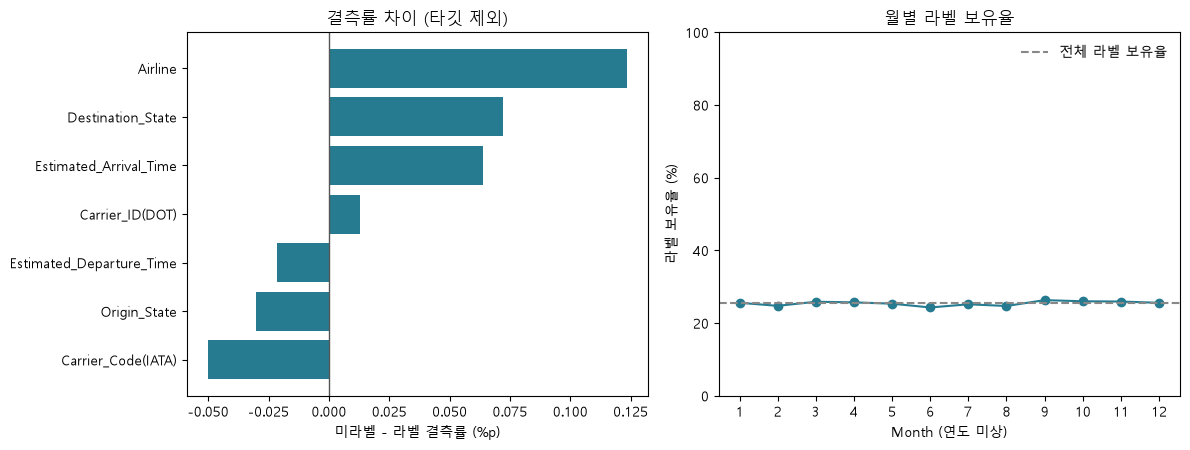

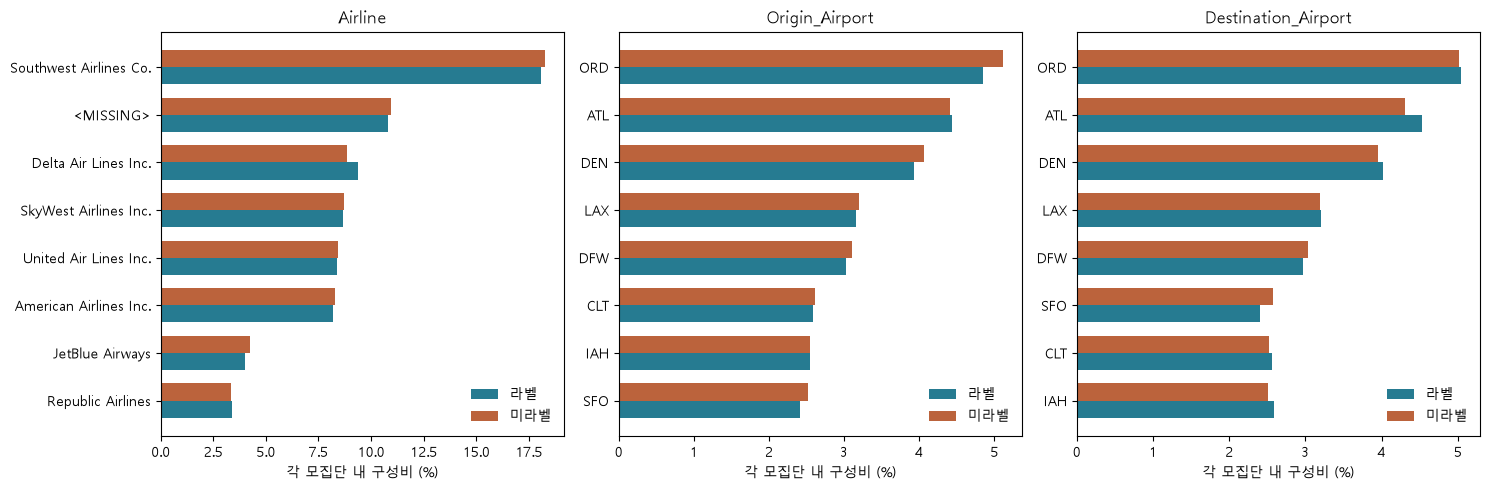

In [2]:

plt.rcParams['font.family']='Malgun Gothic'
plt.rcParams['axes.unicode_minus']=False
fig,axs=plt.subplots(1,2,figsize=(12,4.6))
m=missing[missing.column.ne('Delay')].copy()
m=m.loc[(m.labeled_missing_n+m.unlabeled_missing_n).gt(0)].sort_values('delta_pp')
axs[0].barh(m.column,m.delta_pp,color='#267b91')
axs[0].axvline(0,color='#555555',lw=1)
axs[0].set_xlabel('미라벨 - 라벨 결측률 (%p)'); axs[0].set_title('결측률 차이 (타깃 제외)')
month=groups[groups.column.eq('Month')].copy()
month['month']=month.category.astype(int); month=month.sort_values('month')
axs[1].plot(month.month,month.label_rate_pct,'o-',color='#267b91')
axs[1].axhline(known.mean()*100,color='#888888',ls='--',label='전체 라벨 보유율')
axs[1].set_ylim(0,100); axs[1].set_xticks(range(1,13))
axs[1].set_xlabel('Month (연도 미상)'); axs[1].set_ylabel('라벨 보유율 (%)')
axs[1].set_title('월별 라벨 보유율'); axs[1].legend(frameon=False)
fig.tight_layout(); fig.savefig(OUT/'coverage_overview.png',dpi=160); plt.show()
fig,axs=plt.subplots(1,3,figsize=(15,5))
for ax,col in zip(axs,['Airline','Origin_Airport','Destination_Airport']):
    g=groups[groups.column.eq(col)].nlargest(8,'total_n').sort_values('total_n')
    y=np.arange(len(g))
    ax.barh(y-.18,g.labeled_share*100,height=.36,label='라벨',color='#267b91')
    ax.barh(y+.18,g.unlabeled_share*100,height=.36,label='미라벨',color='#bb633c')
    ax.set_yticks(y,g.category); ax.set_title(col); ax.set_xlabel('각 모집단 내 구성비 (%)')
    ax.legend(frameon=False)
fig.tight_layout(); fig.savefig(OUT/'category_shares.png',dpi=160); plt.show()


In [3]:

def table(frame):
    f=frame.copy().fillna('—')
    return '| '+' | '.join(map(str,f.columns))+' |\n| '+' | '.join(['---']*len(f.columns))+' |\n'+'\n'.join('| '+' | '.join(map(str,r))+' |' for r in f.itertuples(index=False,name=None))
maxmiss=missing[missing.column.ne('Delay')].loc[lambda x:x.delta_pp.abs().idxmax()]
major=dist[dist.column.isin(['Month','Airline','Origin_Airport','Destination_Airport'])]
large=groups[groups.total_n.ge(1000)].copy()
large['gap_from_overall_pp']=large.label_rate_pct-known.mean()*100
top=large.loc[large.gap_from_overall_pp.abs().sort_values(ascending=False).head(12).index]
text=f'''# 라벨 유무 분포 진단 — 실제 전체 데이터

## 범위와 해석

원본 {len(df):,}행, {len(df.columns)}열. 라벨 {known.sum():,}행 ({known.mean():.4%}), 미라벨 {(~known).sum():,}행.
라벨행 양성률 {counts['positive_rate_labeled']:.4%}. ID 중복 {counts['duplicate_id']}, 완전 행 중복 {counts['duplicate_rows']}.
분석 단위는 CSV의 한 행이다. ID가 유일해도 실제 운항편의 유일성을 입증하지는 않는다.
미라벨의 정답은 채우지 않았다. 분석은 원본 컬럼 기준이며 전처리 후 모델 입력의 동등성 검사는 아니다.

## 직접 측정한 결과

타깃을 제외한 결측률의 최대 절대 차이는 **{maxmiss.column}: {maxmiss.delta_pp:+.4f}%p (미라벨-라벨)**다.
주요 저차원 분포(Month/Airline/출발·도착 공항)의 최대 TV는 **{major.total_variation.max():.6f}**다.
TV=0.5×구성비 절대 차이 합이며 0이면 관측 분포가 같다. 통계적 유의수준이나 대표성 합격선이 아니다.

{table(dist.round(6))}

![결측 및 월별 라벨 보유율](label_coverage/coverage_overview.png)

![상위 범주 구성비](label_coverage/category_shares.png)

## 표본 1,000행 이상 그룹의 라벨 보유율 차이

희소 그룹의 극단적 비율을 주요 증거로 쓰지 않기 위한 표시 기준이다. 전체 그룹은 CSV에 보존했다.

{table(top[['column','category','total_n','labeled_n','label_rate_pct','gap_from_overall_pp']].round(4))}

## 결론의 경계

측정된 구성비 차이는 관측된 변수에서의 차이이며, 라벨 선정 과정의 원인을 알려주지 않는다.
고유값이 많은 Tail_Number는 작은 그룹과 표본 크기 차이 때문에 TV가 커질 수 있다. 이를 곧바로 선택 편향으로 판정하지 않는다.
분포가 가까워도 MCAR(완전 무작위 결측), 미라벨의 지연율, 성능 일반화는 입증되지 않는다.
따라서 기존 CV 결과의 직접 적용 범위는 라벨 255,001행이다. 미라벨로의 확대는 가정으로 남긴다.
Month 비교는 계절별 구성 진단이다. 연도가 없어 연속 시계열·장기 추세·미래 검증이라고 부르지 않는다.
HHMM 숫자의 평균·분위수는 원시 표기 비교용이며 평균 시각이나 경과시간으로 해석하지 않는다.
그룹별 observed_delay_rate는 관측 라벨 안에서만 계산했고 인과효과가 아니다.

## 위험과 조치

대표성 미확인: 중요도 중간, 한계의 존재는 확실하나 편향의 방향·크기는 미확인. 라벨 생성/선정 규칙을 확보하기 전 재가중·미라벨 정답 추정을 하지 않는다.
연도·실측/예정 시각 규약 미확인: 미래 예측 주장에는 중요도 높음. 현재는 정적 데이터 과제로 범위를 제한한다.
측정된 분포 차이 자체는 오류로 판정하지 않는다. 전체 구성비·결측률·미관측 범주 비율을 다음 데이터와 비교할 기준으로 보존한다.

## 근거와 재현

원본 `data/train.csv`, SHA256 `{meta['data_sha256']}`.
실행 시각 `{meta['generated_utc']}`. counts/구성비 합계 검증을 코드에서 실행했다.
`uv run --offline python -u notebooks/build_label_coverage_review.py`

실행 노트북: [label_coverage_review.ipynb](../notebooks/label_coverage_review.ipynb).
세부 근거: [그룹 분포](label_coverage/group_distributions.csv), [결측률](label_coverage/missingness.csv),
[수치 분포](label_coverage/numeric_distributions.csv), [원본 스키마](label_coverage/schema.csv), [지문](label_coverage/provenance.json).
'''
(ROOT/'output/label_coverage_review.md').write_text(text,encoding='utf-8')
print(text[:1800])


# 라벨 유무 분포 진단 — 실제 전체 데이터

## 범위와 해석

원본 1,000,000행, 19열. 라벨 255,001행 (25.5001%), 미라벨 744,999행.
라벨행 양성률 17.6470%. ID 중복 0, 완전 행 중복 0.
분석 단위는 CSV의 한 행이다. ID가 유일해도 실제 운항편의 유일성을 입증하지는 않는다.
미라벨의 정답은 채우지 않았다. 분석은 원본 컬럼 기준이며 전처리 후 모델 입력의 동등성 검사는 아니다.

## 직접 측정한 결과

타깃을 제외한 결측률의 최대 절대 차이는 **Airline: +0.1235%p (미라벨-라벨)**다.
주요 저차원 분포(Month/Airline/출발·도착 공항)의 최대 TV는 **0.018086**다.
TV=0.5×구성비 절대 차이 합이며 0이면 관측 분포가 같다. 통계적 유의수준이나 대표성 합격선이 아니다.

| column | categories | total_variation | max_share_gap_pp | unlabeled_rows_in_unseen_categories | unlabeled_unseen_pct |
| --- | --- | --- | --- | --- | --- |
| Tail_Number | 6430 | 0.071678 | 0.018586 | 407 | 0.054631 |
| Origin_Airport | 374 | 0.018086 | 0.266471 | 0 | 0.0 |
| Destination_Airport | 375 | 0.017221 | 0.271511 | 4 | 0.000537 |
| Month | 12 | 0.012418 | 0.453404 | 0 | 0.0 |
| Airline | 29 | 0.010563 | 0.53568 | 0 | 0.0 |
| Destination_State | 53 | 0.009776 | 0.232699 | 0 | 0.0 |
| Carrier_Code(IATA) | 12 | 0.009604 | 0.549023 | 0 | 0.0 |
| Or